# Entrenamiento de modelos

## Configuración del path

In [8]:
# Configuración del path del proyecto
# Permite importar módulos desde la carpeta raíz `Data-science`
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# Se agrega la raíz del proyecto si aún no está incluida.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## Importacion de librerias

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
from src.transformers import TextCleaner
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib


## Importación de dataset

In [10]:
# Importación del dataset
ruta = PROJECT_ROOT / 'data'/ '2_clean_data.csv'

# Leer el archivo
try:
    df_final = pd.read_csv(ruta, encoding='latin1', engine='python', on_bad_lines='skip')
    # Mostrar las primeras filas para verificar
    print("Archivo cargado exitosamente.")
    display(df_final.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo cargado exitosamente.


,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive


## Feature Engineering y entrenamiento de modelos

En esta etapa se realizará el feature engeineering, para el cual se realizará la vectorización del texto del dataset limpio, mediante TF-IDF.

Además, se entrenarán los modelos de Naive Bayes y Regresión Logística y se evaluarán las métricas para elegir el modelo que realiza una mejor clasificación de los comentarios.
Todos estos pasos estarán unidos en un pipeline para facilitar la ejecución de todas las etapas.

In [11]:
# Visualización del dataframe
df_final

,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive
...,...,...,...
568449,Great for sesame chicken..this is a good if no...,great sesame chickenthis good better resturant...,Positive
568450,I'm disappointed with the flavor. The chocolat...,im disappointed flavor chocolate notes especia...,Negative
568451,"These stars are small, so you can give 10-15 o...",stars small training session tried train dog c...,Positive
568452,These are the BEST treats for training and rew...,best treats training rewarding dog good groomi...,Positive


### Definición de Target y Features.

En esta etapa, se definen los Features y el Target del dataset final. 
- Feature: columna 'Text', que es el texto original que el modelo debe analizar.
- Target: columna 'sentiment' que es la clasificación que se le da al tono del texto del comentario (positivo, neutro o negativo).

Además, se separa el dataset en datos de prueba (test) y de entrenamiento (train) para poderlos utilizar en los modelos.

In [12]:
# 1. Definimos X (features) y y (target)
X = df_final['Text']
y = df_final['sentiment']

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.to_frame(name="text")
X_test  = X_test.to_frame(name="text")


### Pipeline para modelo de Naive Bayes

En esta etapa, se crea un pipeline que incluye la vectorización del texto y la utilización de varios modelos de Naive Bayes con diferentes combinaciones de hiperparámetros para poder realizar la clasificación de los comentarios.

En el entrenamiento del modelo, se obtienen los hiperparámetros que tuvieron mejor rendimiento (mejor F1 score) para obtener el modelo final entrenado.

In [21]:
# ======================================================
# Pipeline 1: TF-IDF + Naive Bayes
# ======================================================
# Este pipeline integra en un solo flujo:
# 1. Manejo de valores faltantes (NaN)
# 2. Limpieza y normalización del texto
# 3. Vectorización mediante TF-IDF
# 4. Entrenamiento de un clasificador Naive Bayes
#
# La ventaja de este enfoque es que todo el preprocesamiento
# se aprende únicamente a partir del conjunto de entrenamiento,
# evitando data leakage y facilitando la reutilización del modelo
# en entornos productivos (ej. backend o API).
# ======================================================


# Definición del pipeline completo
pipeline_nb = Pipeline([

    # Paso 1: Imputación de valores faltantes
    # Los valores NaN se reemplazan por strings vacíos para evitar
    # errores en los pasos posteriores de procesamiento de texto.
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),

    # Paso 2: Limpieza del texto
    # Se aplica la normalización, eliminación de símbolos,
    # URLs y stopwords directamente sobre el texto crudo.
    ("cleaner", TextCleaner()),

    # Paso 3: Vectorización TF-IDF
    # Convierte el texto limpio en una representación numérica
    # basada en la importancia relativa de cada término.
    ("tfidf", TfidfVectorizer()),

    # Paso 4: Modelo de clasificación
    # Se utiliza Multinomial Naive Bayes
    ("clf", MultinomialNB())
])


# ======================================================
# Definición de la grilla de hiperparámetros
# ======================================================
# Se exploran diferentes configuraciones tanto del
# vectorizador TF-IDF como del clasificador Naive Bayes
# para encontrar la combinación que maximice el desempeño.
# ======================================================

param_grid_nb = {
    # Número máximo de términos considerados en el vocabulario
    'tfidf__max_features': [3000, 5000, 7000],

    # Uso de unigramas y bigramas para capturar contexto
    'tfidf__ngram_range': [(1,1), (1,2)],

    # Parámetro de suavizado de Laplace del modelo Naive Bayes
    'clf__alpha': [0.1, 0.5, 1.0]
}

# ======================================================
# Búsqueda de hiperparámetros con GridSearchCV
# ======================================================
# GridSearchCV evalúa todas las combinaciones posibles
# utilizando validación cruzada, seleccionando el modelo
# que obtiene el mejor desempeño promedio.
# ======================================================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_nb = GridSearchCV(
    estimator=pipeline_nb,
    param_grid=param_grid_nb,
    cv=cv,                  # validación cruzada de 3 folds
    scoring='f1_macro',     # métrica para elegir la mejor configuración del modelo. Robusta para clases desbalanceadas.
    verbose=2,
    n_jobs=1            
)


# ======================================================
# Entrenamiento del modelo
# ======================================================
# El pipeline completo (limpieza + vectorización + modelo)
# se entrena exclusivamente con el conjunto de entrenamiento.
# ======================================================
grid_nb.fit(X_train, y_train)


# ======================================================
# Resultados
# ======================================================
# Se muestran los mejores hiperparámetros encontrados
# durante el proceso de búsqueda.
# ======================================================
print("Mejores parámetros - Naive Bayes:", grid_nb.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 2.3min
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 1.9min
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 1.7min
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 3.1min
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 1.9min
[CV] END clf__alpha=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 2.0min
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.3min
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.2min
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.2min
[CV] END clf__alpha=0.1, tfidf__max_features=5000, tfidf__ngram_ra

In [22]:
# Modelo de Naive Bayes entrenado
best_nb_model = grid_nb.best_estimator_

# Predicciones con el modelo de Naive Bayes
y_pred_nb = best_nb_model.predict(X_test)

# Evaluación del F1 score del modelo de Naive Bayes
f1_nb = f1_score(y_test, y_pred_nb, average='macro') 

# Mostrar resultado
print(f"El F1-score del modelo de Naive Bayes es: {f1_nb}")

El F1-score del modelo de Naive Bayes es: 0.4833952886571995


### Pipeline para modelo de Regresión Logística

En esta etapa, se crea un pipeline que incluye la vectorización del texto mediante TF-IDF y la utilización de varios modelos de Regresión Logística con diferentes combinaciones de hiperparámetros para poder realizar la clasificación de los comentarios.

En el entrenamiento del modelo, se obtienen los hiperparámetros que tuvieron mejor rendimiento (mejor F1 score) para obtener el modelo final entrenado.

In [16]:
# ======================================================
# Pipeline 2: TF-IDF + Regresión Logística
# ======================================================

pipeline_lr = Pipeline([
    # 1. Manejo de valores nulos
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),

    # 2. Ejecución del transformer personalizado
    ("cleaner", TextCleaner()),

    # 3. Vectorización
    ("tfidf", TfidfVectorizer(min_df = 5, dtype=np.float32)),

    # 4. Clasificador con pesos balanceados para clases desbalanceadas
    ("clf", LogisticRegression(max_iter=1000, class_weight='balanced'))
])


# ======================================================
# Grilla de Hiperparámetros
# ======================================================

param_grid_lr = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    
    # Fuerza de regularización (menor valor = más regularización)
    'clf__C': [0.1, 1, 10],
    
}


# ======================================================
# Configuración de Validación y Búsqueda
# ======================================================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    verbose=2,
    n_jobs=1 
)

# Entrenamiento
grid_lr.fit(X_train, y_train)

# Mejor combinación encontrada en el modelo de Regresión Logística
print("Mejores parámetros - Regresión Logística:", grid_lr.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 1.4min
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 1.4min
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 1); total time= 1.2min
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 2.5min
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 2.4min
[CV] END clf__C=0.1, tfidf__max_features=3000, tfidf__ngram_range=(1, 2); total time= 2.1min
[CV] END clf__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.6min
[CV] END clf__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.6min
[CV] END clf__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 1); total time= 1.4min
[CV] END clf__C=0.1, tfidf__max_features=5000, tfidf__ngram_range=(1, 2); total time= 2.3min
[CV] END 

En esta etapa, se realizan las predicciones con el mejor modelo obtenido en el paso anterior y se calcula el F1 score para poder cuantificar y comparar el rendimiento del modelo.

In [17]:
# Modelo de Regresión Logística entrenado
best_lr_model = grid_lr.best_estimator_

# Predicciones con el modelo de Regresión Logística
y_pred_lr = best_lr_model.predict(X_test)

# Evaluación del F1 score del modelo de Regresión Logística
f1_lr = f1_score(y_test, y_pred_lr, average='macro') 

# Mostrar resultado
print(f"El F1-score del modelo de Regresión Logística es: {f1_lr}")

El F1-score del modelo de Regresión Logística es: 0.6499326376991643


Como resultados de los dos pipeline ejecutados, se tiene:

1. Mejores parámetros:
    - Modelo de Regresión logística: {'clf__C': 1, 'tfidf__max_features': 7000, 'tfidf__ngram_range': (1, 2)}
    - Modelo de Naive Bayes:{'clf__alpha': 0.1, 'tfidf__max_features': 7000, 'tfidf__ngram_range': (1, 2)}

2. F1 Score:
    - Modelo de Regresión Logística: 0.65
    - Modelo de Naive Bayes: 0.48

Por lo tanto, de acuerdo a los resultados del F1 Score, se concluye que el modelo de Regresión Logística es el mejor de los dos modelos para poder clasificar los textos.

### Métricas del mejor modelo: Regresión Logística

#### Acuracy, Precision, Recall y F1 Score

In [18]:
# Métricas del mejor modelo: Regresión Logística
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print('\n')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7894380381912377


              precision    recall  f1-score   support

    Negative       0.64      0.75      0.69     16407
     Neutral       0.27      0.63      0.38      8528
    Positive       0.97      0.81      0.88     88756

    accuracy                           0.79    113691
   macro avg       0.63      0.73      0.65    113691
weighted avg       0.87      0.79      0.82    113691



De acuerdo a las métricas obtenidas del modelo, se puede concluir que:

1. **Fortalezas**

    - **Alta confiabilidad en sentimientos positivos:** El modelo exhibe una precisión sobresaliente del 0.97 en la clase positiva. Esto garantiza que las predicciones de satisfacción del cliente son altamente veraces, aunque existe un margen de mejora para capturar un 19% de comentarios positivos que actualmente se omiten (Recall = 0.81).

    - **Capacidad de detección crítica (Recall Negativo):** Con un recall de 0.75 en la clase negativa, el modelo funciona como un filtro efectivo para la gestión de crisis, logrando identificar 3 de cada 4 comentarios de insatisfacción.

2. **Aspectos por mejorar**

    - **Ambigüedad en la clase Neutral:** La baja precisión (0.27) en comentarios neutros indica una alta tasa de falsos positivos en esta categoría. El modelo tiende a clasificar erróneamente comentarios con carga emocional como neutros, lo que sugiere la necesidad de optimizar el vocabulario del TfidfVectorizer para distinguir mejor la neutralidad de la sutileza.

    - **Optimización del desbalance:** Dado que la clase positiva domina el dataset (aprox. 78% de los datos), el modelo presenta un sesgo natural. Se podría explorar técnicas de balanceo adicionales para mejorar el desempeño en la clase con menor representación (Neutral).

#### Confusion Matrix

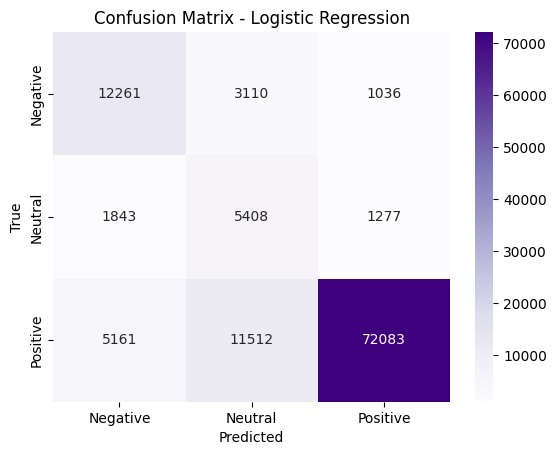

In [19]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr, labels=["Negative","Neutral","Positive"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

De la matriz de confusión, se pude concluir que:

- **Identificación del Sesgo de Neutralidad:** La baja precisión en la categoría Neutral se debe principalmente a un solapamiento con la clase Positiva. El modelo tiende a 'suavizar' las opiniones positivas, clasificando erróneamente más de 11,500 comentarios satisfactorios como neutros.

- **Fugas de comentarios críticos:** Se identificó que un 19% de los comentarios negativos (3,110 casos) están siendo filtrados hacia la categoría neutral, lo que representa el riesgo principal de omisión en la detección de insatisfacción.

- **Efectividad en Positivos**: Aunque el recall de la clase positiva es del 0.81, la matriz muestra que la gran mayoría de las fallas se desplazan a 'Neutral' y no a 'Negativo', lo que indica que el modelo rara vez confunde polos opuestos (amor vs. odio).

### Exportación del modelo

Se realiza la exportación del pipeline del modelo ganador (Regresión Logística), que incluye tanto el proceso de vectorización como la ejecución del modelo con los mejores parámetros establecidos.

In [20]:
# Exportacion del pipeline de Regresión Logística

model = joblib.dump(best_lr_model, PROJECT_ROOT/'models'/'sentiment_lr.joblib')